# Extended Data Figure 5 — inverse folding

Reproduces the panels of this figure. Each cell runs a released producer and shows its output.

**Default level is 1** — redraw from a table shipped in the Zenodo deposit. No model, no GPU;
seconds on a laptop. Cells that need a GPU or a checkpoint are marked and left commented out.

Run from the `peint-paper` repository, or set `PEINT_PAPER_REPO` to point at it.

In [1]:
import os, sys, subprocess, pathlib, shutil, tempfile, hashlib
# Locate the peint-paper checkout by looking for its marker files, walking up from the
# working directory. Do NOT resolve a relative ".." here: this cell chdirs to PAPER_REPO
# below, so a relative default would climb one directory on every re-run -- and re-running a
# setup cell is the most ordinary thing anyone does in a notebook. Searching for the marker
# is idempotent: once cwd is the repo root, the root is what the search finds.
def _find_paper_repo():
    env = os.environ.get("PEINT_PAPER_REPO")
    if env:
        return pathlib.Path(env).resolve()
    here = pathlib.Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "paper_config.py").exists() and (d / "figures").is_dir():
            return d
    # beside it: this notebook may have been copied somewhere outside the repository, so
    # also look for a checkout hanging off any ancestor
    for d in (here, *here.parents):
        for cand in (d / "repos" / "peint-paper", d / "peint-paper"):
            if (cand / "paper_config.py").exists() and (cand / "figures").is_dir():
                return cand
    raise RuntimeError(
        "Could not find the peint-paper checkout from " + str(here) +
        ". Set PEINT_PAPER_REPO to the repository root, or run this notebook from inside it."
    )

PAPER_REPO = _find_paper_repo()
os.environ.setdefault("PEINT_PAPER_PEINT_REPO", str(PAPER_REPO.parent / "peint"))
os.environ["PEINT_PAPER_LOCAL_DATA_ONLY"] = "1"
os.chdir(PAPER_REPO)
sys.path.insert(0, str(PAPER_REPO))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# Inline display needs IPython. These notebooks are also executed headlessly in CI, where it is
# absent, so fall back to printing rather than failing the whole notebook on the import.
try:
    from IPython.display import display, Image
    _INLINE = True
except ImportError:
    _INLINE = False
    def display(x): print(x)
    def Image(filename=None, width=None): return f"[figure written to {filename}]"

# When the current batch of producers started. A cell may call run() several times before a
# single show(); comparing against the LAST run would falsely flag whatever the earlier runs
# wrote. The timestamp is set by the first run() of a batch and cleared by show(), so the
# question asked is "did this panel appear during this cell", not "during the latest command".
_last_run = [0.0, False]   # [batch start, batch open]

def run(module, *args):
    """Run a panel producer and show its output."""
    import time
    cmd = [sys.executable, "-m", module, *args]
    print("$", " ".join(cmd[2:]))
    if not _last_run[1]:
        _last_run[0], _last_run[1] = time.time(), True
    r = subprocess.run(cmd, capture_output=True, text=True)
    tail = [l for l in r.stdout.split("\n") if l.strip()][-15:]
    print("\n".join(tail))
    if r.returncode:
        print(f"\n  *** FAILED (exit {r.returncode}) ***")
        print("  " + r.stderr.strip().split("\n")[-1][:400])
    return r.returncode == 0

_PREVIEW_DIR = pathlib.Path(tempfile.mkdtemp(prefix="peint_panel_preview_"))

def _rasterize(pdf):
    """Render page 1 of a PDF to a PNG so it can be shown inline; None if nothing here can.

    Several panels -- all of Figure 4 -- are only ever written as PDF. The PDF stays the
    artifact of record: this is a throwaway display copy in a scratch dir, redone whenever the
    PDF is newer than it.
    """
    pdf = pathlib.Path(pdf)
    png = _PREVIEW_DIR / (hashlib.md5(str(pdf).encode()).hexdigest()[:10] + ".png")
    if png.exists() and png.stat().st_mtime >= pdf.stat().st_mtime:
        return png
    try:
        import fitz                                   # PyMuPDF, if it happens to be installed
        fitz.open(pdf)[0].get_pixmap(dpi=200).save(png)
        return png
    except Exception:
        pass
    stem = str(png.with_suffix(""))
    for cmd in (["pdftoppm", "-png", "-r", "200", "-singlefile", str(pdf), stem],
                ["pdftocairo", "-png", "-r", "200", "-singlefile", str(pdf), stem],
                ["convert", "-density", "200", str(pdf) + "[0]", "-flatten", str(png)]):
        if not shutil.which(cmd[0]):
            continue
        if subprocess.run(cmd, capture_output=True).returncode == 0 and png.exists():
            return png
    return None

def _show_file(p, w=760, check_stale=True):
    """Show one panel file inline: a PNG as-is, a PDF through a rasterized display copy.

    ``check_stale=False`` is for panels committed to the repository that this notebook cannot
    regenerate (Fig 4a/4b/4d) -- there the mtime says nothing, so the check is waived at the
    call site rather than quietly skipped.
    """
    p = pathlib.Path(p)
    if check_stale and p.stat().st_mtime < _last_run[0]:
        print(f"  *** STALE: {p.name} predates the run above -- it did not regenerate. "
              f"The image below is from an earlier run; do not read numbers off it. ***")
    img = p if p.suffix == ".png" else _rasterize(p)
    if img is None:
        print(f"  {p.name} written, but no PDF rasterizer (poppler's pdftoppm, or PyMuPDF) "
              f"is installed to show it inline")
        return
    width = w
    try:                                              # never upscale a small panel to w px
        from PIL import Image as _PILImage
        with _PILImage.open(img) as im:
            width = min(w, im.width)
    except Exception:
        pass
    display(Image(filename=str(img), width=width))

def show(*names, w=760, check_stale=True):
    """Display panel images inline, by name relative to figures/.

    A bare name is looked up in figures/output/ ("figure3_conservation_lg_s256"); a name with a
    subdirectory anywhere under figures/ ("spearman_agg/spearman_plot_esm_150m"). The extension
    is optional -- the PNG is preferred, and a PDF-only panel is rasterized rather than merely
    reported, so every panel can be held up against the printed figure.

    A panel file older than the producer call above it is left over from an earlier run --
    displaying it silently would show you a figure that does not match the code you just ran,
    so say so rather than pretending it is fresh.
    """
    _last_run[1] = False          # close the batch: a later run() starts a new one
    figs = PAPER_REPO / "figures"
    for n in names:
        for p in (figs / f"{n}.png", figs / f"{n}.pdf",
                  figs / "output" / f"{n}.png", figs / "output" / f"{n}.pdf", figs / n):
            if p.exists() and p.suffix in (".png", ".pdf"):
                _show_file(p, w, check_stale)
                break
        else:
            print("  not found:", n)

def compare(label, computed, printed, tol=0.05):
    """Print the value this notebook computed beside the one in the manuscript."""
    ok = "MATCH" if abs(computed - printed) <= tol else "CHECK"
    print(f"  {label:<28} computed {computed:>8.3f}   manuscript {printed:>8.3f}   {ok}")

## 5d, 5e — ESM-IF likelihood and sequence recovery

Level 2. Needs the trRosetta structures (5d) and the `r1_omegafold` role (5e, 12.4 GB).
Budget roughly an hour on one GPU; **check that a GPU is actually visible first** — the
script falls back to CPU silently, which turns an hour into most of a day.

If a panel title carries an **INCOMPLETE** marker, that is the producer telling you model
coverage was partial for that run — it is part of the result, not a rendering artefact.

CUDA visible: False
  no GPU: showing the panels already in figures/output/esmif (the CPU path takes ~9.5 h)


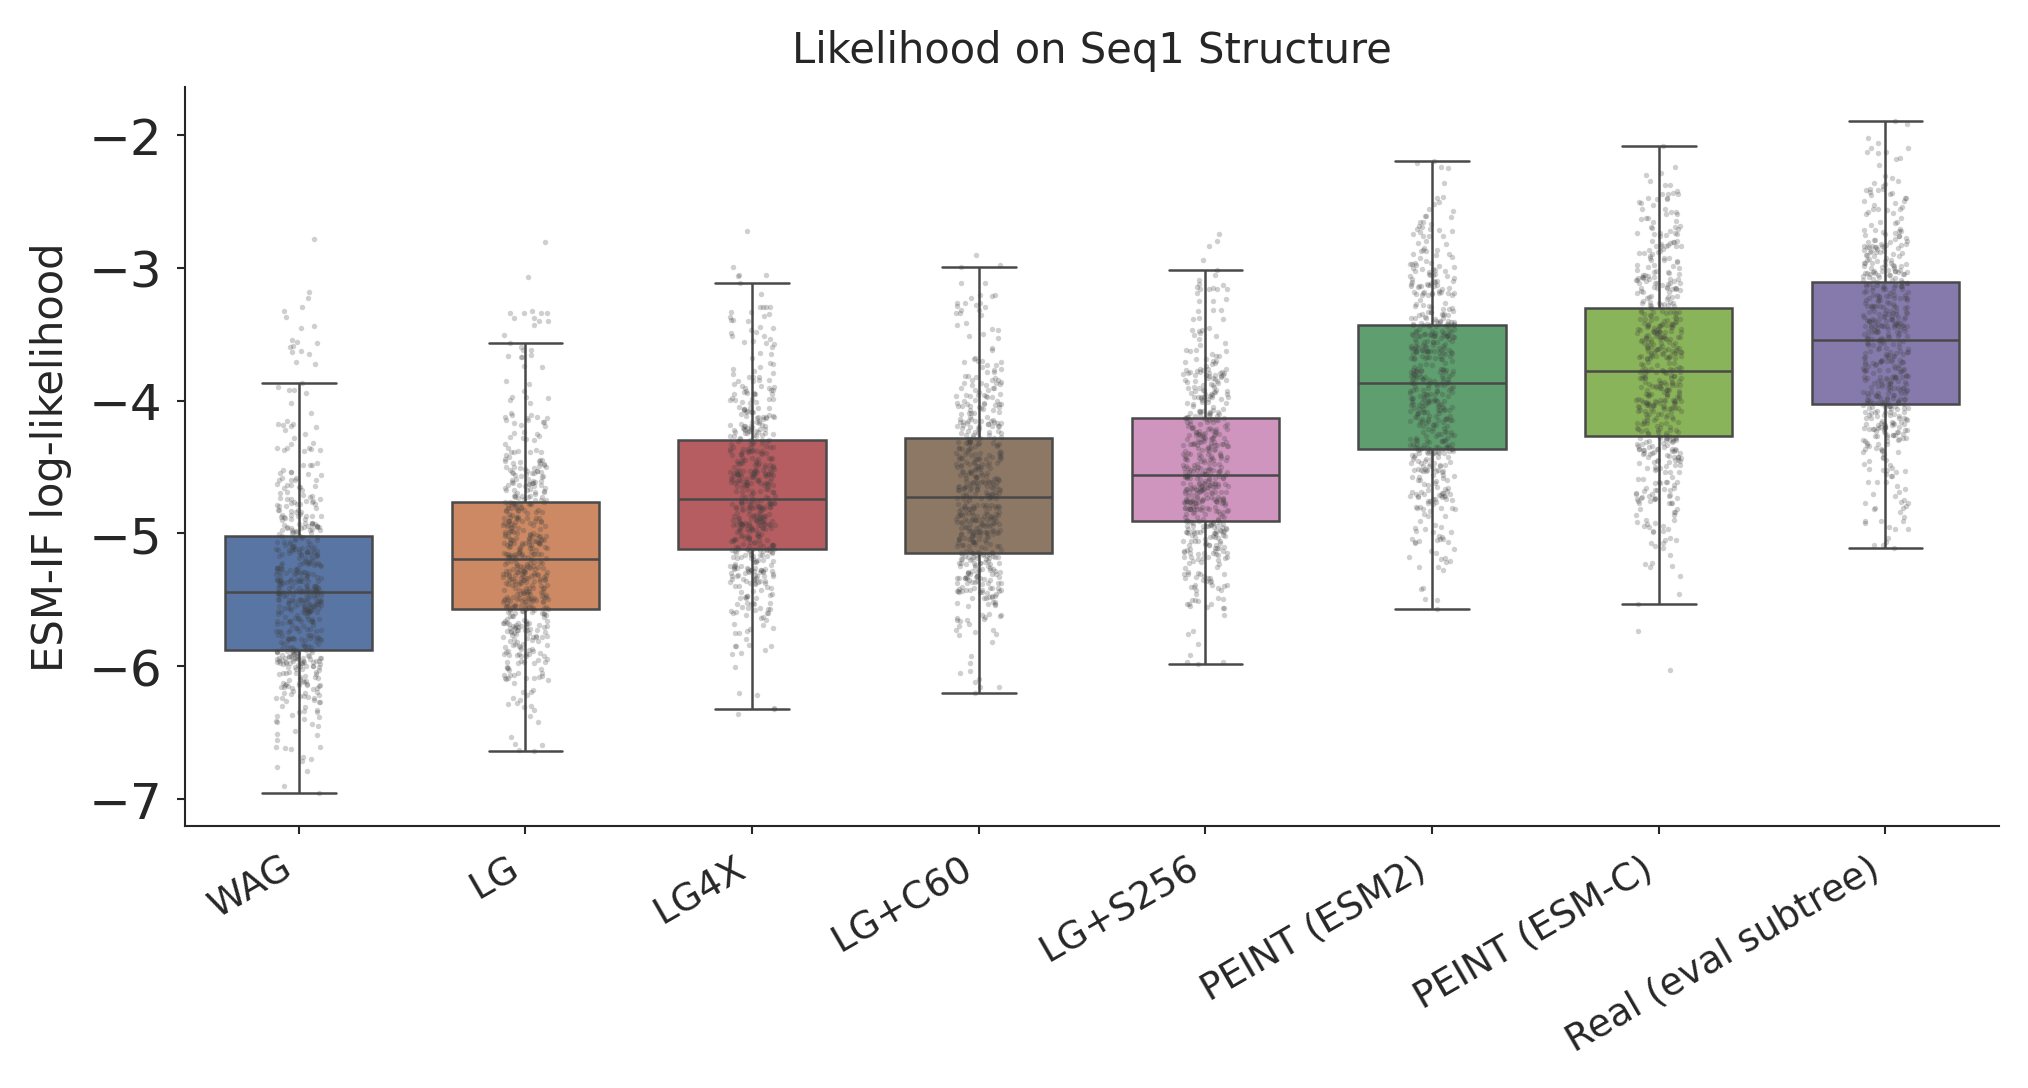

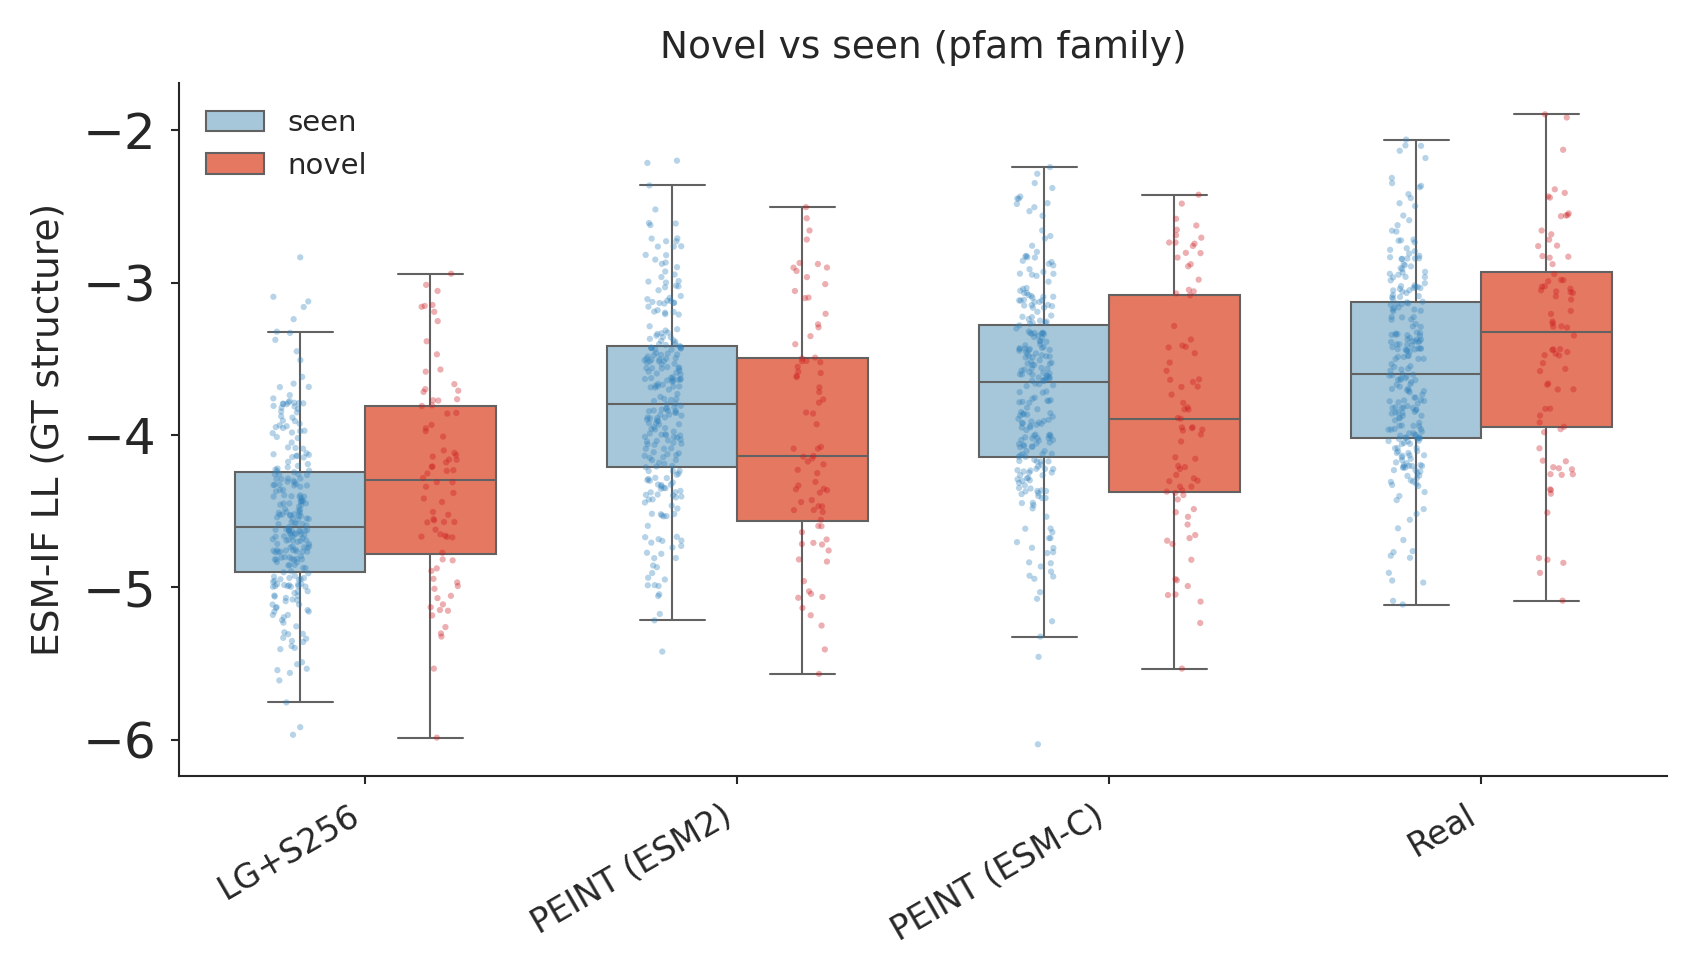

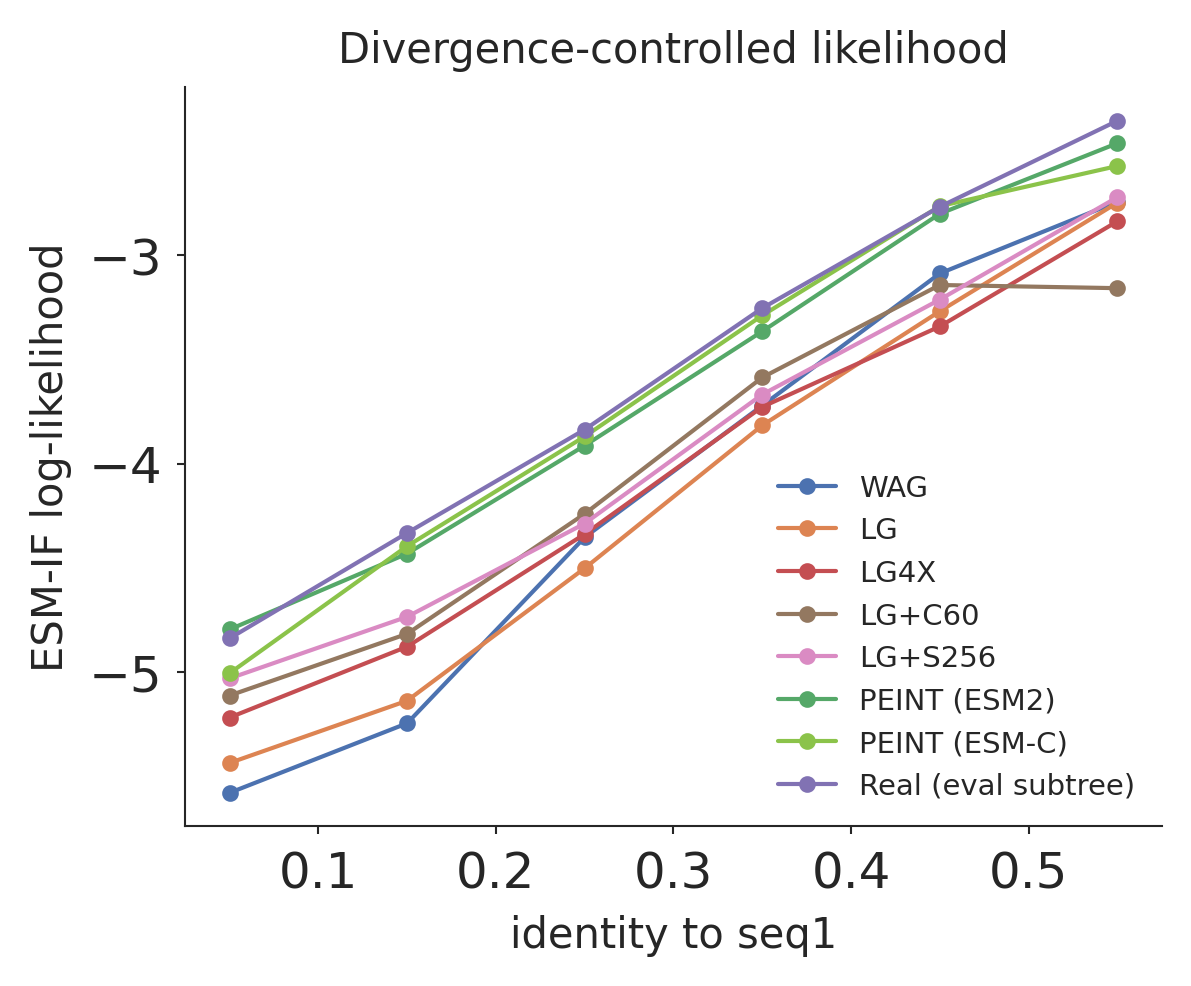

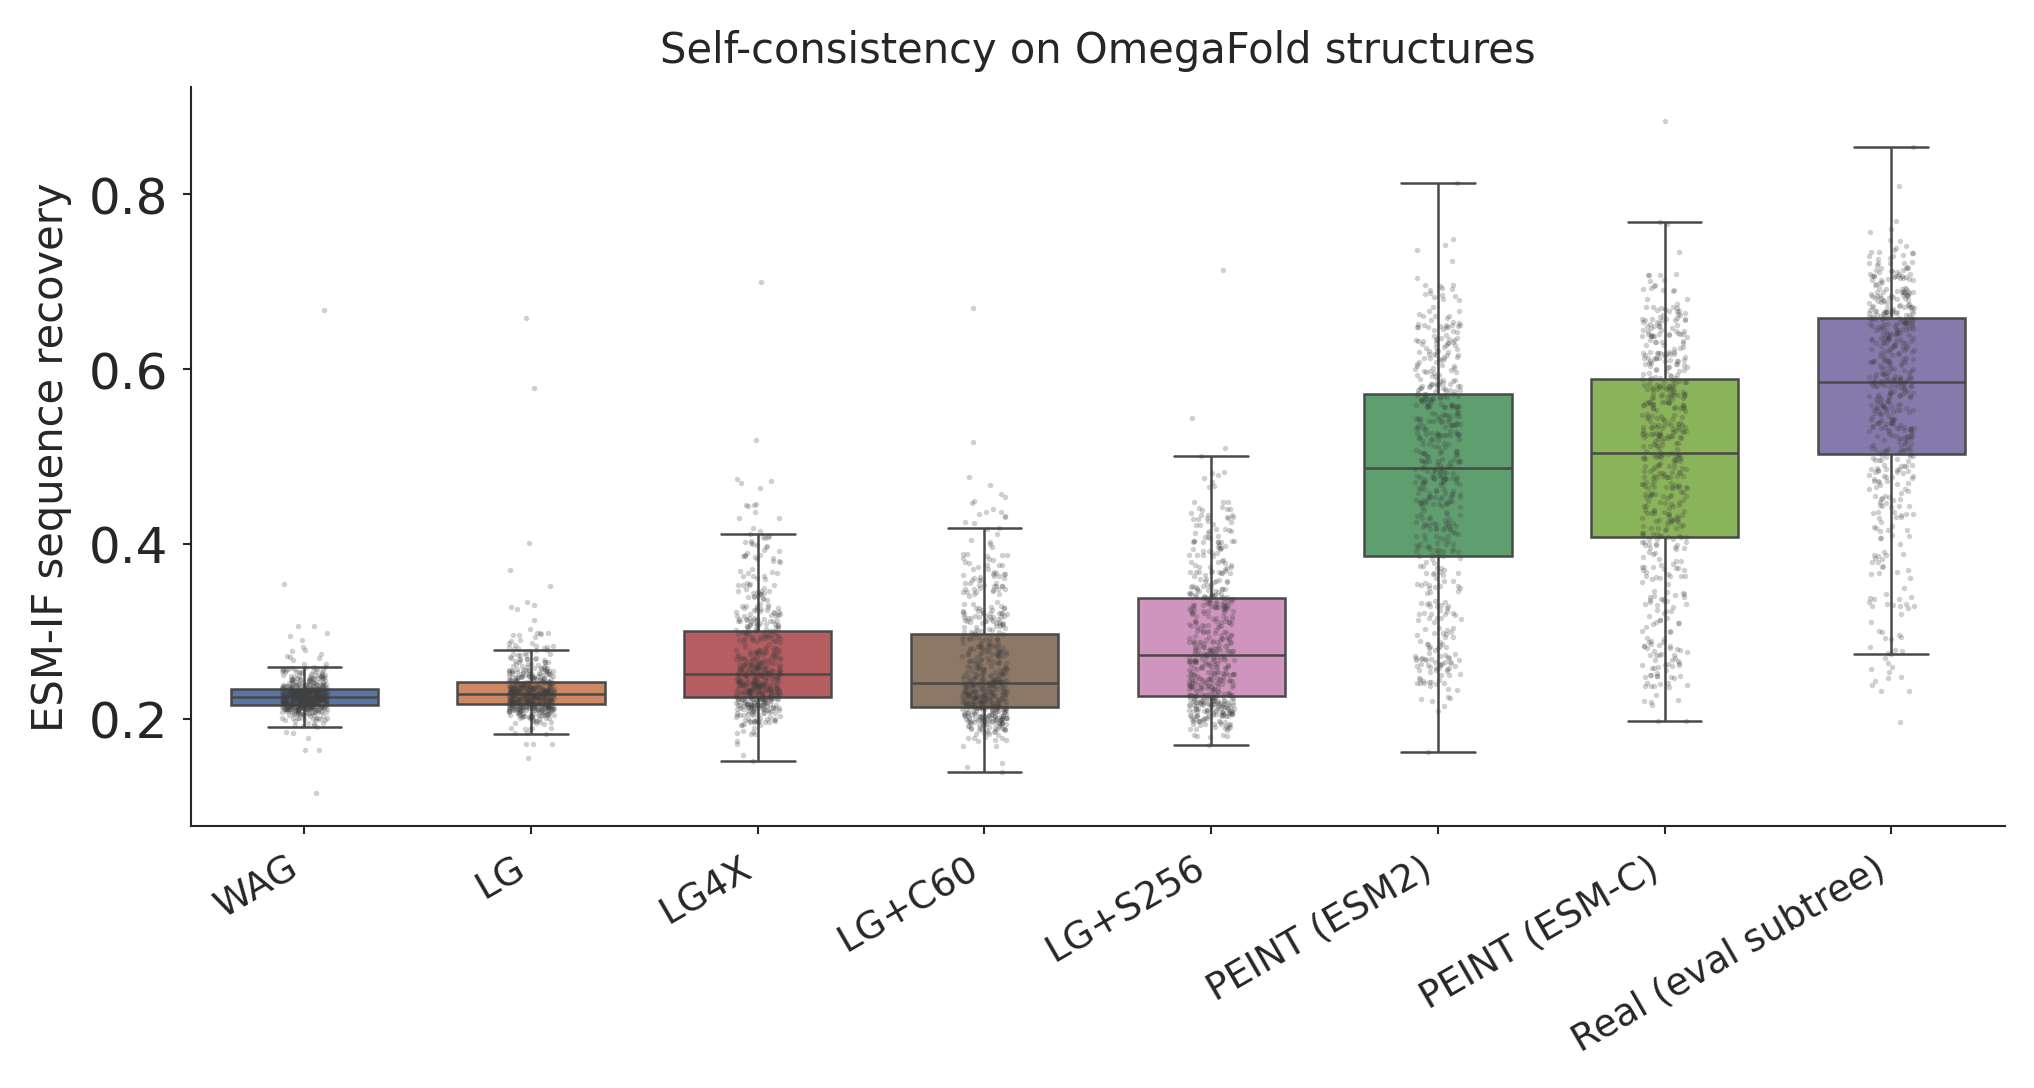

In [2]:
# The panels already on disk display without a GPU -- only regenerating them needs one, so
# the run is gated and the show() below is not.
import torch
print("CUDA visible:", torch.cuda.is_available())
if torch.cuda.is_available():
    run("benchmarks.esmif_validation", "--approach", "both")
else:
    print("  no GPU: showing the panels already in figures/output/esmif "
          "(the CPU path takes ~9.5 h)")
show("output/esmif/esmif_approach1_gt_likelihood",              # 5d
     "output/esmif/esmif_gt_likelihood_stratified",             # 5d, stratified cut
     "output/esmif/esmif_approach1_divergence_controlled",      # 5d, divergence-matched
     "output/esmif/esmif_approach2_selfconsistency")            # 5e

## 5b, 5c — the AlphaFold2-with-MSA table is not yet recovered

These two panels compare against AlphaFold2 predictions made *with* an MSA. That table was
produced for the original analysis but is not part of the current data release, and we have
not yet recovered it from the run that made it. It is the only input these two panels need,
so there is nothing to run here until it is restored. This is a missing input, not a known
issue with the panels themselves.